# Multivariate

## Read File CSV

In [1]:
from pathlib import Path

# 1. Kiểm tra thư mục gốc project
print("Project folder:", Path.cwd())

# 2. Kiểm tra xem có thư mục data không
print("Có thư mục data không?", Path("data").exists())

# 3. Liệt kê tất cả file csv trong project
for p in Path(".").rglob("*.csv"):
    print(p)

Project folder: d:\data-mining-project\notebooks
Có thư mục data không? True
data\cleaned\cleaned_customers.csv
data\cleaned\cleaned_items.csv
data\cleaned\cleaned_orders.csv
data\cleaned\cleaned_payments.csv
data\cleaned\cleaned_products.csv
data\cleaned\cleaned_sellers.csv
data\cleaned\olist_customers.csv


In [2]:
from pathlib import Path
import pandas as pd

# Đọc trực tiếp file olist_customers.csv
file_path = Path("data/cleaned/olist_customers.csv")
df = pd.read_csv(file_path)
df

,frequency,customer_zip_code_prefix,customer_city,customer_state,recency,monetary,total_item,unique_category,favorite_category,payment_type_diversity,dominant_payment_type,avg_delivery_days,avg_shipping_delay,late_delivery_ratio,avg_freight_ratio,avg_freight_value,avg_estimated_gap
0,1,7787,cajamar,SP,112,141.90,1,1,cama_mesa_banho,1,credit_card,6.0,-5.0,0.0,0.084567,12.00,10.0
1,1,6053,osasco,SP,115,27.19,1,1,beleza_saude,1,credit_card,3.0,-5.0,0.0,0.304892,8.29,7.0
2,1,88115,sao jose,SC,537,86.22,1,1,papelaria,1,credit_card,25.0,-2.0,0.0,0.199722,17.22,27.0
3,1,66812,belem,PA,321,43.62,1,1,telefonia,1,credit_card,20.0,-12.0,0.0,0.404172,17.63,31.0
4,1,18040,sorocaba,SP,288,196.89,1,1,telefonia,1,credit_card,13.0,-8.0,0.0,0.085784,16.89,20.0
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
93349,1,55250,sanharo,PE,447,2067.42,2,1,beleza_saude,1,credit_card,27.0,-27.0,0.0,0.242553,248.71,54.0
93350,1,44054,feira de santana,BA,262,84.58,1,1,bebes,1,credit_card,30.0,-3.0,0.0,0.232797,19.69,32.0
93351,1,78552,sinop,MT,568,112.46,1,1,automotivo,1,credit_card,14.0,-30.0,0.0,0.200605,22.56,44.0
93352,1,29460,bom jesus do norte,ES,119,133.69,1,1,relogios_presentes,1,credit_card,11.0,-14.0,0.0,0.139801,18.69,25.0


## Numerical

### Spearman Correlation

Data có nhiều outlier nên sử dụng Spearman

| Nhóm biến                                    | Nhận xét ngắn                                                                                                                 |
| -------------------------------------------- | ----------------------------------------------------------------------------------------------------------------------------- |
| `frequency` – `unique_category`              | Tương quan dương khá mạnh (0.62) → khách mua nhiều thường mua đa dạng danh mục hơn.                                           |
| `frequency` – `total_item`                   | Tương quan dương trung bình (0.42) → mua thường xuyên thì tổng số sản phẩm cũng tăng.                                         |
| `monetary` – `avg_freight_ratio`             | Tương quan âm mạnh (-0.69) → đơn hàng giá trị cao thường có tỷ lệ phí vận chuyển thấp hơn so với giá trị đơn.                 |
| `monetary` – `avg_freight_value`             | Tương quan dương trung bình (0.50) → giá trị đơn cao thì phí ship tuyệt đối cũng tăng.                                        |
| `avg_shipping_delay` – `avg_estimated_gap`   | Tương quan âm khá mạnh (-0.56) → khoảng thời gian dự kiến giao càng dư thì delay thực tế càng thấp.                           |
| `avg_delivery_days` – `avg_estimated_gap`    | Tương quan dương trung bình (0.52) → đơn giao lâu thường được estimate thời gian rộng hơn.                                    |
| `avg_shipping_delay` – `late_delivery_ratio` | Tương quan dương trung bình (0.47) → delay cao dẫn đến tỷ lệ giao trễ tăng.                                                   |
| `avg_delivery_days` – `avg_freight_value`    | Tương quan dương trung bình (0.43) → giao lâu hơn thường đi kèm phí vận chuyển cao hơn.                                       |
| `payment_type_diversity`                     | Hầu như không tương quan mạnh với các biến khác.                                                                              |
| `recency`                                    | Gần như không có tương quan đáng kể với đa số biến → thời gian mua gần nhất khá độc lập.                                      |
| Tổng quan                                    | Phần lớn các biến có tương quan yếu đến trung bình, không có hiện tượng multicollinearity quá mạnh ngoài một vài cặp nổi bật. |


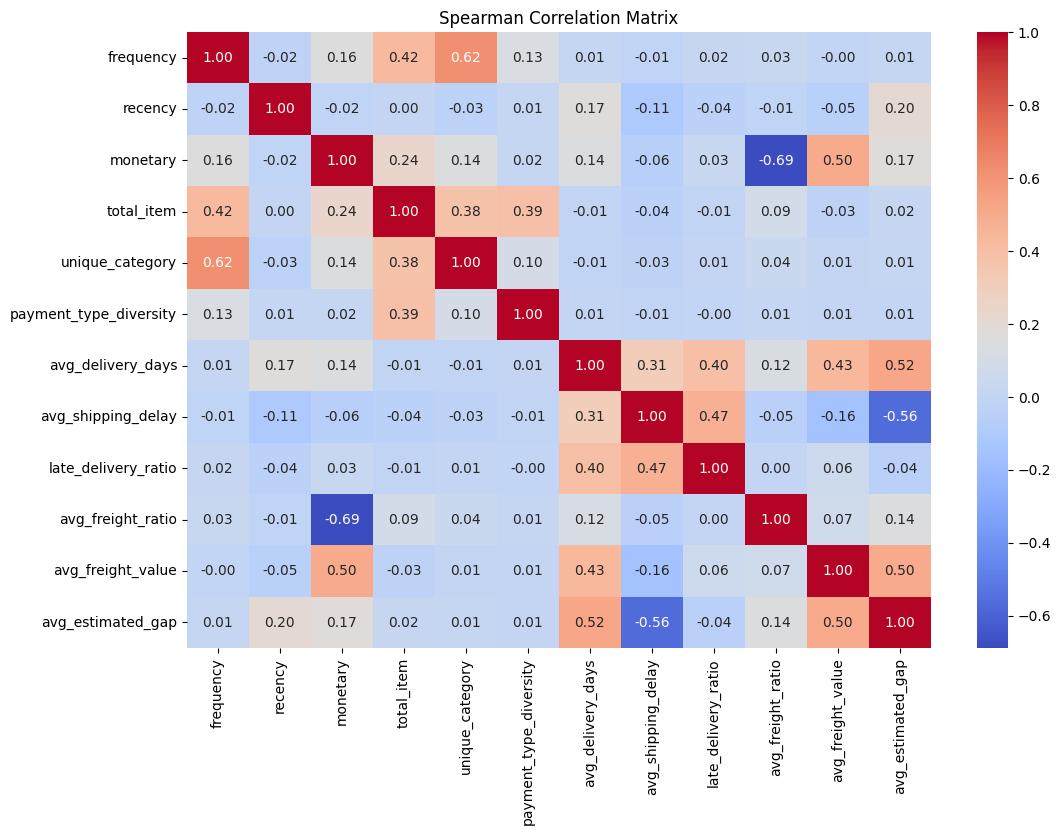

In [3]:
import seaborn as sns
import matplotlib.pyplot as plt

num_cols = [
    'frequency',
    'recency',
    'monetary',
    'total_item',
    'unique_category',
    'payment_type_diversity',
    'avg_delivery_days',
    'avg_shipping_delay',
    'late_delivery_ratio',
    'avg_freight_ratio',
    'avg_freight_value',
    'avg_estimated_gap'
]

# Spearman correlation
corr = df[num_cols].corr(method='spearman')

plt.figure(figsize=(12,8))
sns.heatmap(corr, annot=True, cmap='coolwarm', fmt='.2f')

plt.title('Spearman Correlation Matrix')
plt.show()

### Scatter plot

Nghi vấn tuyến tính giữa 2 biến avg_delivery_days và avg_shipping_delay

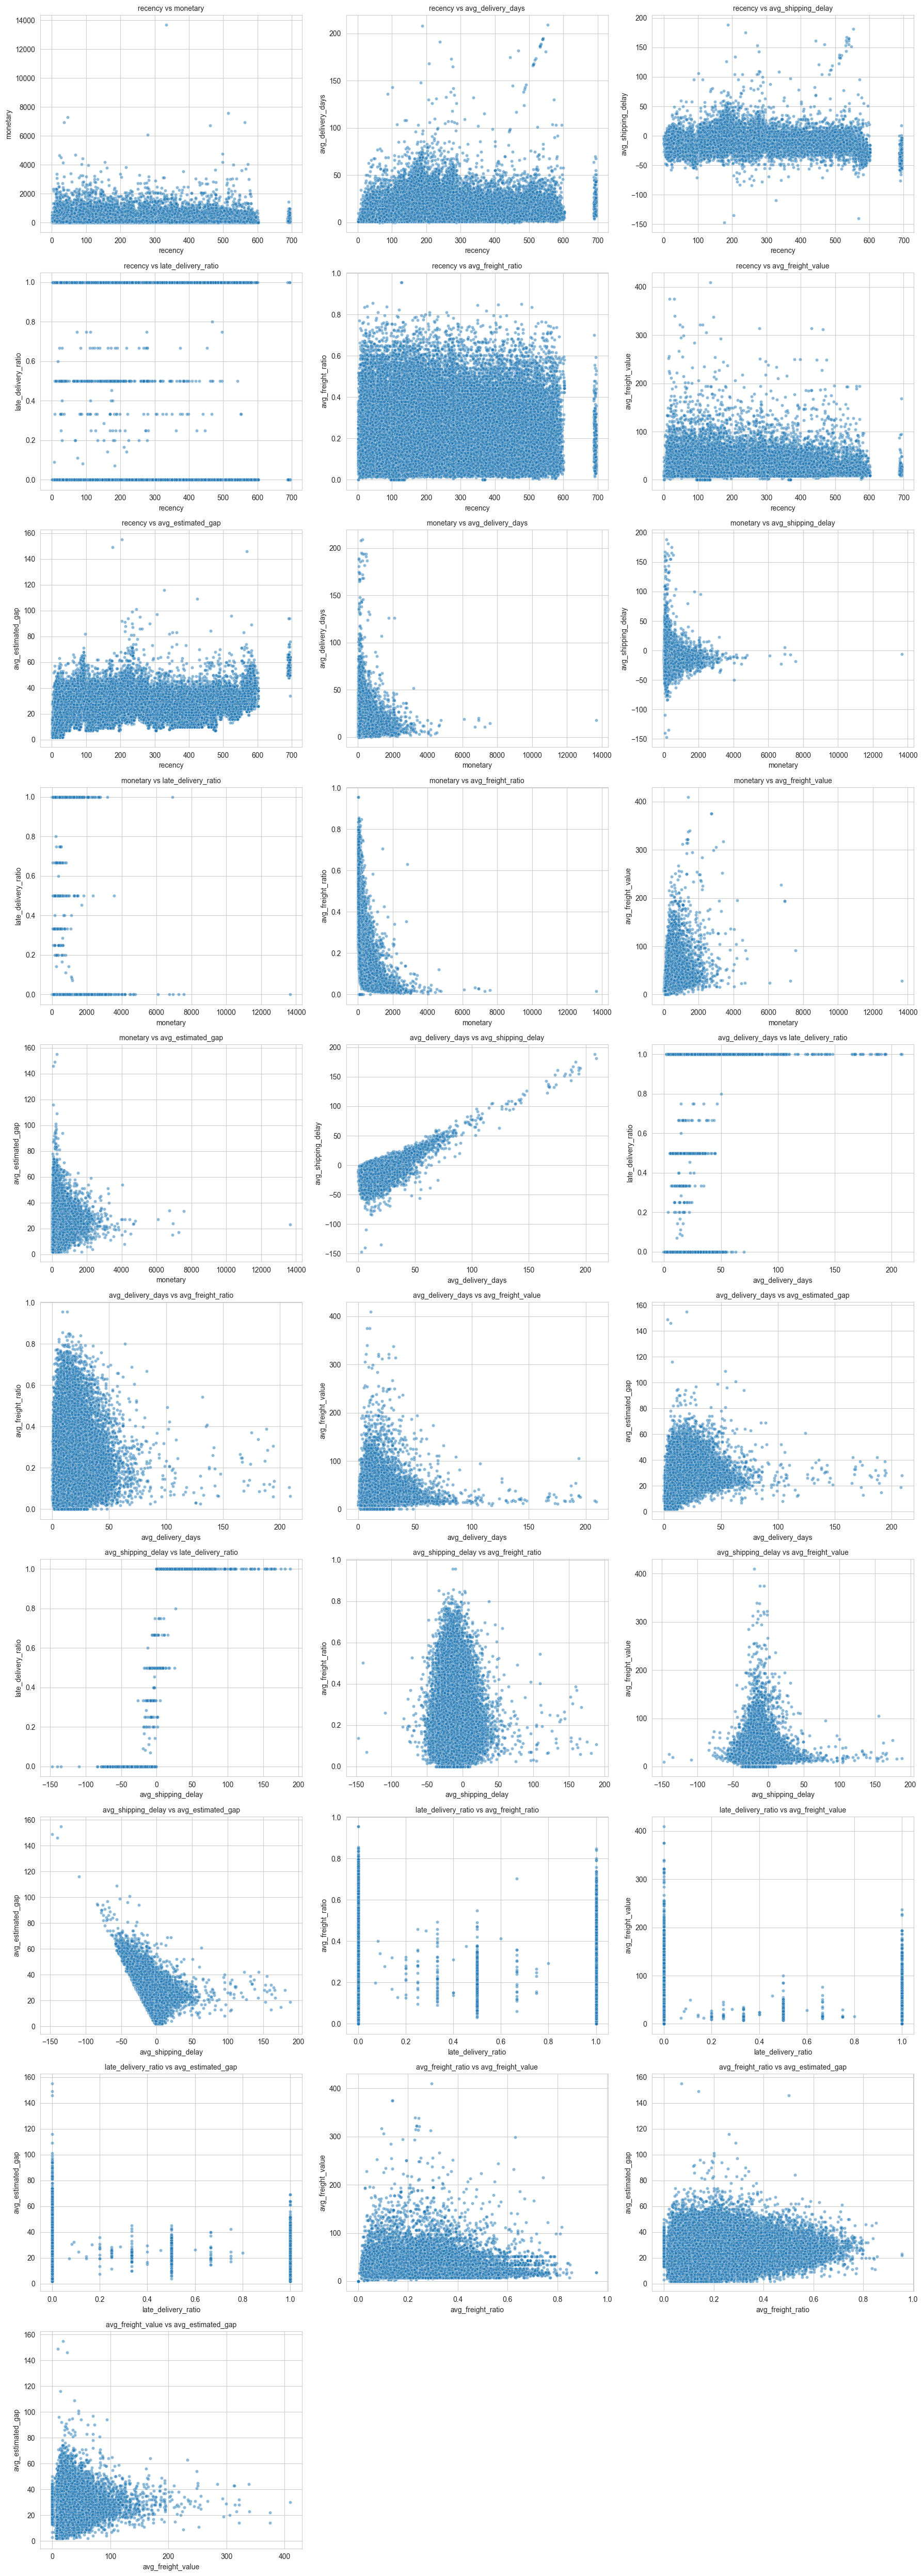

In [8]:
import math
import pandas as pd
import seaborn as sns
import matplotlib.pyplot as plt
from itertools import combinations

# ===== NUMERICAL COLUMNS =====
num_cols = [
    'recency',
    'monetary',
    'avg_delivery_days',
    'avg_shipping_delay',
    'late_delivery_ratio',
    'avg_freight_ratio',
    'avg_freight_value',
    'avg_estimated_gap'
]

# ===== DATA =====
df_plot = df[num_cols].copy()

# ===== ALL VARIABLE PAIRS =====
pairs = list(combinations(num_cols, 2))

# ===== SUBPLOT SETTINGS =====
n_cols = 3   # số plot mỗi hàng
n_rows = math.ceil(len(pairs) / n_cols)

fig, axes = plt.subplots(
    n_rows,
    n_cols,
    figsize=(18, 5 * n_rows)
)

axes = axes.flatten()

sns.set_style("whitegrid")

# ===== DRAW SCATTER PLOTS =====
for i, (x_col, y_col) in enumerate(pairs):
    
    sns.scatterplot(
        data=df_plot,
        x=x_col,
        y=y_col,
        alpha=0.5,
        s=20,
        ax=axes[i]
    )
    
    axes[i].set_title(f'{x_col} vs {y_col}', fontsize=10)

# ===== REMOVE EMPTY SUBPLOTS =====
for j in range(i + 1, len(axes)):
    fig.delaxes(axes[j])

plt.tight_layout()
plt.show()

### Check quan hệ tuyến tính

Biến avg_delivery_days và avg_shipping_delay có quan hệ tuyến tính chứ không chỉ monotomic 

Pearson correlation: 0.6100
P-value: 0.0000e+00


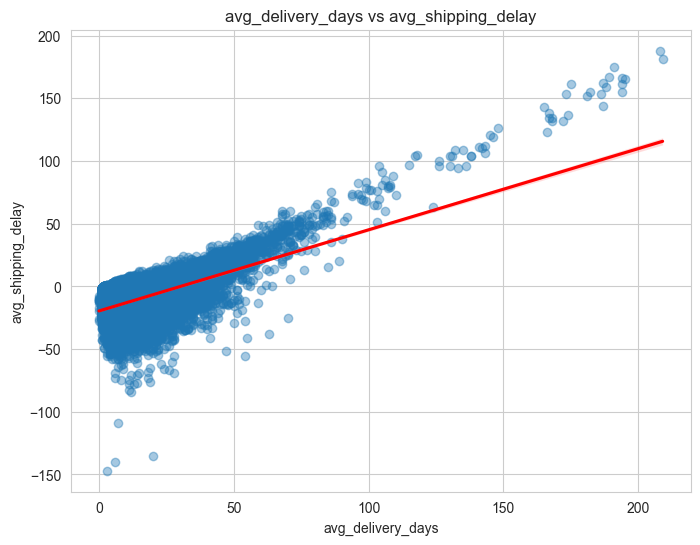

In [9]:
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from scipy.stats import pearsonr

# Chọn 2 biến
x = df['avg_delivery_days']
y = df['avg_shipping_delay']

# Xóa missing
temp = pd.DataFrame({
    'avg_delivery_days': x,
    'avg_shipping_delay': y
}).dropna()

# Pearson correlation
corr, p_value = pearsonr(
    temp['avg_delivery_days'],
    temp['avg_shipping_delay']
)

print(f'Pearson correlation: {corr:.4f}')
print(f'P-value: {p_value:.4e}')

# Scatter plot + regression line
plt.figure(figsize=(8,6))

sns.regplot(
    data=temp,
    x='avg_delivery_days',
    y='avg_shipping_delay',
    scatter_kws={'alpha':0.4},
    line_kws={'color':'red'}
)

plt.title('avg_delivery_days vs avg_shipping_delay')
plt.xlabel('avg_delivery_days')
plt.ylabel('avg_shipping_delay')

plt.show()

## Categorical

### Chi-square Test

In [5]:
import pandas as pd
from itertools import combinations
from scipy.stats import chi2_contingency

# ===== NOMINAL COLUMNS =====
nominal_cols = [
    'customer_zip_code_prefix',
    'customer_city',
    'customer_state',
    'favorite_category',
    'dominant_payment_type'
]

# ===== CHI-SQUARE TEST =====
results = []

for col1, col2 in combinations(nominal_cols, 2):

    # drop missing values
    temp = df[[col1, col2]].dropna()

    # contingency table
    table = pd.crosstab(temp[col1], temp[col2])

    # chi-square test
    chi2, p, dof, expected = chi2_contingency(table)

    results.append({
        'Variable 1': col1,
        'Variable 2': col2,
        'Chi2 Statistic': round(chi2, 2),
        'p-value': p,
        'Degrees of Freedom': dof,
        'Significant (p < 0.05)': p < 0.05
    })

# ===== RESULT DATAFRAME =====
chi_square_results = pd.DataFrame(results)

# sort by p-value
chi_square_results = chi_square_results.sort_values(
    by='p-value'
)
chi_square_results


,Variable 1,Variable 2,Chi2 Statistic,p-value,Degrees of Freedom,Significant (p < 0.05)
0,customer_zip_code_prefix,customer_city,3.792864e+08,0.000000e+00,60774004,True
1,customer_zip_code_prefix,customer_state,2.427204e+06,0.000000e+00,386906,True
4,customer_city,customer_state,2.376062e+06,0.000000e+00,106184,True
7,customer_state,favorite_category,4.098490e+03,3.122361e-163,1898,True
9,favorite_category,dominant_payment_type,8.900200e+02,1.157302e-81,219,True
8,customer_state,dominant_payment_type,4.228200e+02,8.074186e-49,78,True
2,customer_zip_code_prefix,favorite_category,1.099841e+06,3.115851e-20,1086313,True
3,customer_zip_code_prefix,dominant_payment_type,4.596421e+04,5.908401e-06,44643,True
5,customer_city,favorite_category,3.011148e+05,5.886297e-05,298132,True
6,customer_city,dominant_payment_type,1.205152e+04,9.003390e-01,12252,False


### Cramér’s V Test

In [6]:
import pandas as pd
import numpy as np
from itertools import combinations
from scipy.stats import chi2_contingency

# ===== NOMINAL COLUMNS =====
nominal_cols = [
    'customer_zip_code_prefix',
    'customer_city',
    'customer_state',
    'favorite_category',
    'dominant_payment_type'
]

# ===== CRAMÉR'S V FUNCTION =====
def cramers_v(x, y):
    confusion_matrix = pd.crosstab(x, y)

    chi2 = chi2_contingency(confusion_matrix)[0]
    n = confusion_matrix.sum().sum()

    r, k = confusion_matrix.shape

    return np.sqrt(chi2 / (n * (min(k - 1, r - 1))))

# ===== PAIRWISE CORRELATION =====
results = []

for col1, col2 in combinations(nominal_cols, 2):

    # drop missing
    temp = df[[col1, col2]].dropna()

    score = cramers_v(temp[col1], temp[col2])

    results.append({
        'Variable 1': col1,
        'Variable 2': col2,
        "Cramér's V": round(score, 4)
    })

# ===== RESULT TABLE =====
corr_nominal = pd.DataFrame(results)

# sort descending
corr_nominal = corr_nominal.sort_values(
    by="Cramér's V",
    ascending=False
)
corr_nominal

,Variable 1,Variable 2,Cramér's V
1,customer_zip_code_prefix,customer_state,1.0000
0,customer_zip_code_prefix,customer_city,0.9974
4,customer_city,customer_state,0.9894
3,customer_zip_code_prefix,dominant_payment_type,0.4051
2,customer_zip_code_prefix,favorite_category,0.4017
5,customer_city,favorite_category,0.2102
6,customer_city,dominant_payment_type,0.2074
9,favorite_category,dominant_payment_type,0.0564
7,customer_state,favorite_category,0.0411
8,customer_state,dominant_payment_type,0.0389


| Nhóm quan hệ | Cặp biến | Chi-square (p-value) | Cramér’s V | Nhận xét |
|--------------|----------|----------------------|------------|----------|
| Rất mạnh (trùng thông tin) | zip_code ↔ city | p ≈ 0 | 0.9974 | Gần như 1-1, dư thừa |
| Rất mạnh (trùng thông tin) | zip_code ↔ state | p ≈ 0 | 1.0000 | Phụ thuộc gần tuyệt đối |
| Rất mạnh (trùng thông tin) | city ↔ state | p ≈ 0 | 0.9894 | Quan hệ phân cấp rõ ràng |
| Trung bình | zip_code ↔ favorite_category | p rất nhỏ | 0.4017 | Có ảnh hưởng vùng miền |
| Trung bình | zip_code ↔ dominant_payment_type | p rất nhỏ | 0.4051 | Có ảnh hưởng vùng miền |
| Yếu | city ↔ favorite_category | p rất nhỏ | 0.2102 | Ảnh hưởng nhẹ |
| Yếu | city ↔ dominant_payment_type | p rất nhỏ | 0.2074 | Ảnh hưởng nhẹ |
| Rất yếu | favorite_category ↔ dominant_payment_type | p rất nhỏ | 0.0564 | Gần như độc lập |
| Rất yếu | state ↔ favorite_category | p rất nhỏ | 0.0411 | Gần như độc lập |
| Rất yếu | state ↔ dominant_payment_type | p rất nhỏ | 0.0389 | Gần như độc lập |
| Không ý nghĩa | city ↔ dominant_payment_type | p = 0.90 | ~0 | Không liên quan |

# Summary

| Feature                                           | Nhóm      | Quyết định             | Lý do chính                                                                                                               |
| ------------------------------------------------- | --------- | ---------------------- | ------------------------------------------------------------------------------------------------------------------------- |
| `customer_zip_code_prefix`                        | Địa lý    | Drop                 | Tương quan cực cao với `city` và `state` (V ≈ 0.99–1.00) → gần như dư thừa hoàn toàn, chứa cùng thông tin phân cấp        |
| `customer_city`                                   | Địa lý    | Drop (nếu giữ state) | Trùng mạnh với `state` và `zip_code_prefix`, cardinality cao → dễ gây sparse encoding và không thêm nhiều signal mới      |
| `customer_state` *(hoặc city)*                    | Địa lý    | Giữ 1 trong 2       | Chỉ nên giữ 1 biến đại diện vùng miền để tránh redundancy; `state` thường ổn định hơn và ít category hơn                  |
| `avg_freight_value`                               | Logistics | Optional Drop       | Bị overlap với `monetary` và `avg_freight_ratio` (corr ≈ 0.5); ít thông tin chuẩn hóa hơn ratio, dễ gây multicollinearity |
| `avg_delivery_days` **hoặc** `avg_shipping_delay` | Logistics | Drop 1 biến          | Hai biến có quan hệ tuyến tính rõ ràng → đo gần cùng một hiện tượng (delivery timing), giữ 1 để tránh redundancy          |
